# CIFAR-10 Exploration and Preprocessing

This notebook covers the first stage of the assignment: loading the CIFAR-10 dataset, inspecting its structure, visualizing sample images, and preprocessing the images so they can be used with a pretrained ResNet50 model.

## Objectives
- import the necessary libraries
- load CIFAR-10 into `train_images`, `test_images`, `train_labels`, and `test_labels`
- inspect dataset shapes and class distribution
- visualize sample images
- preprocess the images using `tensorflow.keras.applications.resnet50.preprocess_input`
- document reasoning and trade-offs for presentation and submission


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications.resnet50 import preprocess_input

sns.set_style('whitegrid')
np.random.seed(42)
tf.random.set_seed(42)


## 1. Load the dataset

CIFAR-10 contains 60,000 color images of size 32×32 across 10 classes. The dataset is already split into training and testing sets, which makes it convenient for benchmarking image classification pipelines.


In [21]:
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print('train_images shape:', train_images.shape)
print('train_labels shape:', train_labels.shape)
print('test_images shape: ', test_images.shape)
print('test_labels shape: ', test_labels.shape)


train_images shape: (50000, 32, 32, 3)
train_labels shape: (50000, 1)
test_images shape:  (10000, 32, 32, 3)
test_labels shape:  (10000, 1)


## 2. Basic inspection

We inspect the data types and pixel range before preprocessing. This helps verify that the images are in the expected raw integer format.


In [22]:
print('Image dtype:', train_images.dtype)
print('Label dtype:', train_labels.dtype)
print('Min pixel value:', train_images.min())
print('Max pixel value:', train_images.max())


Image dtype: uint8
Label dtype: uint8
Min pixel value: 0
Max pixel value: 255


## 3. Class distribution

Even though CIFAR-10 is designed to be balanced, it is still useful to verify the number of examples per class. This is part of a good exploratory workflow and gives us evidence that class imbalance is not a major concern here.


In [23]:
train_label_flat = train_labels.flatten()
test_label_flat = test_labels.flatten()

train_distribution = pd.Series(train_label_flat).value_counts().sort_index()
test_distribution = pd.Series(test_label_flat).value_counts().sort_index()

distribution_df = pd.DataFrame({
    'class_name': class_names,
    'train_count': train_distribution.values,
    'test_count': test_distribution.values
})

distribution_df


,class_name,train_count,test_count
0,airplane,5000,1000
1,automobile,5000,1000
2,bird,5000,1000
3,cat,5000,1000
4,deer,5000,1000
5,dog,5000,1000
6,frog,5000,1000
7,horse,5000,1000
8,ship,5000,1000
9,truck,5000,1000


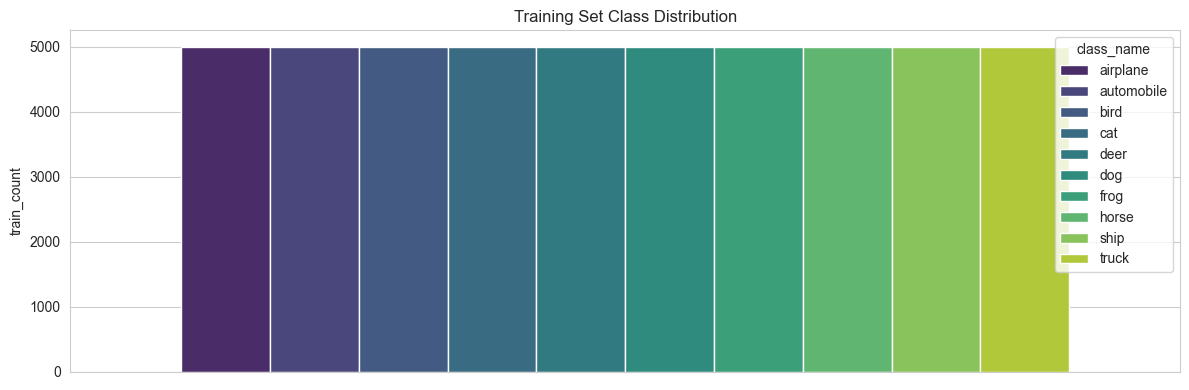

In [24]:
plt.figure(figsize=(12, 4))
sns.barplot(data=distribution_df, hue='class_name', y='train_count', palette='viridis')
plt.title('Training Set Class Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 4. Visualize sample images

CIFAR-10 is challenging because the images are very small, many classes are visually similar, and objects may appear at different positions or with background clutter. Viewing sample images helps confirm that the classes are reasonable and also highlights the difficulty of the task.


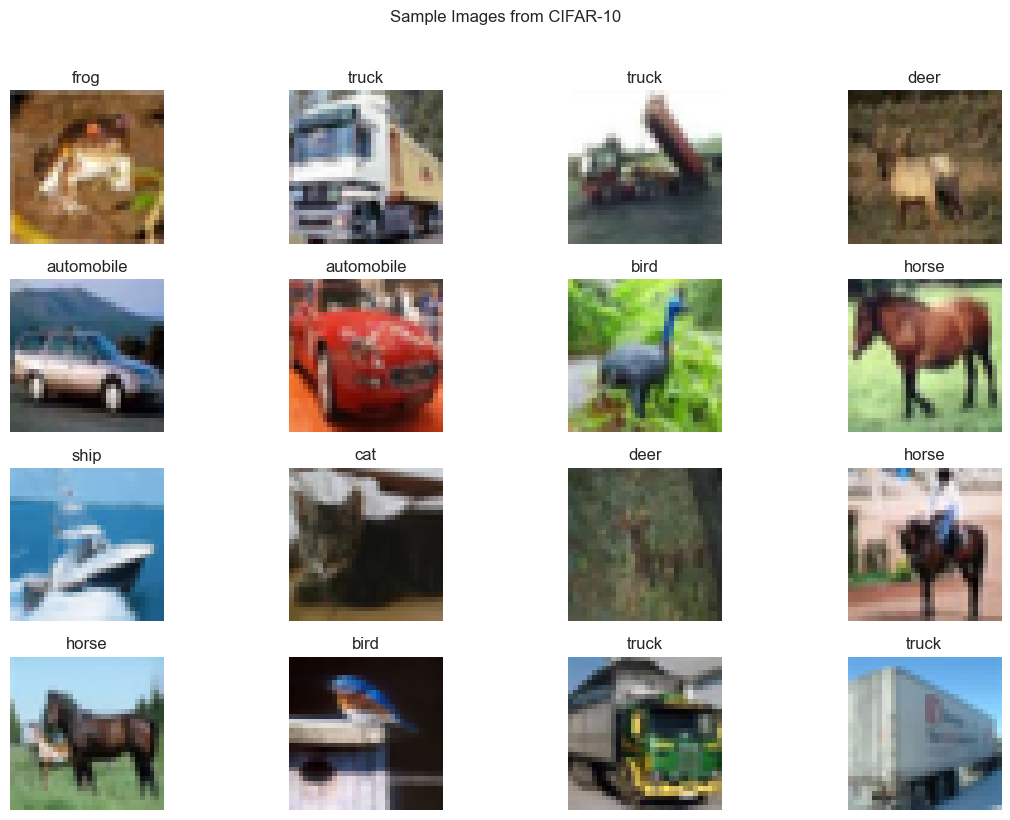

In [25]:
plt.figure(figsize=(12, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(train_images[i])
    plt.title(class_names[train_labels[i][0]])
    plt.axis('off')

plt.suptitle('Sample Images from CIFAR-10', y=1.02)
plt.tight_layout()
plt.show()


## 5. Preprocessing strategy

The assignment requires transfer learning with ResNet50 and ImageNet weights. Because the base model was pretrained on ImageNet, we should preprocess the images using the corresponding `preprocess_input` function from `tensorflow.keras.applications.resnet50`.

This step is important because pretrained models expect pixel values in a specific transformed format. Using the matching preprocessing function helps keep the new inputs aligned with what the pretrained network saw during original training.

We do **not** resize the images because the assignment explicitly asks us to use `input_shape=(32, 32, 3)`.


In [26]:
train_images_preprocessed = preprocess_input(train_images.astype('float32'))
test_images_preprocessed = preprocess_input(test_images.astype('float32'))

print('Preprocessed train shape:', train_images_preprocessed.shape)
print('Preprocessed test shape:', test_images_preprocessed.shape)
print('Preprocessed dtype:', train_images_preprocessed.dtype)


Preprocessed train shape: (50000, 32, 32, 3)
Preprocessed test shape: (10000, 32, 32, 3)
Preprocessed dtype: float32


## 6. Inspect preprocessed values

The raw images use integer values from 0 to 255. After preprocessing, the values are transformed to the format expected by ResNet50. We inspect a few summary statistics to confirm that preprocessing worked.


In [27]:
print('Raw image range:', float(train_images.min()), 'to', float(train_images.max()))
print('Preprocessed image range:', float(train_images_preprocessed.min()), 'to', float(train_images_preprocessed.max()))
print('Example label:', class_names[train_labels[0][0]])


Raw image range: 0.0 to 255.0
Preprocessed image range: -123.68000030517578 to 151.06100463867188
Example label: frog


## 7. Save final variables for modeling notebook

The assignment specifically asks us to work with the variables `train_images`, `test_images`, `train_labels`, and `test_labels`. We keep those original variables available and also create preprocessed versions for model training.

In the next notebook, we will reuse the same dataset loading logic and build the transfer learning pipeline.


In [28]:
print('Original variables ready:')
print('- train_images')
print('- test_images')
print('- train_labels')
print('- test_labels')
print('Additional modeling variables ready:')
print('- train_images_preprocessed')
print('- test_images_preprocessed')


Original variables ready:
- train_images
- test_images
- train_labels
- test_labels
Additional modeling variables ready:
- train_images_preprocessed
- test_images_preprocessed


## 8. Analytical notes

### Why these preprocessing steps were chosen
- We converted images to `float32` because deep learning libraries generally expect floating-point tensors during training.
- We used `preprocess_input` specifically for ResNet50 because transfer learning works best when new inputs are prepared in the same way as the original pretraining inputs.
- We did not resize the images because the assignment required `input_shape=(32, 32, 3)`.

### Constraints and limitations at this stage
- CIFAR-10 images are only 32×32, which makes fine-grained visual details difficult to detect.
- ResNet50 was originally pretrained on much larger natural images, so this setup may not be fully optimal.
- Training and especially fine-tuning may still take significant time depending on local hardware.

### What this notebook achieved
This notebook established a clean and reproducible input pipeline. That is important because strong modeling depends on correct data preparation and a clear understanding of the dataset before training begins.
